In [ ]:
import torch
from torchvision.datasets.mnist import MNIST
import torchvision.transforms as transforms
import numpy as np
import random
import os
import pandas as pd
import torch.nn as nn
from collections import defaultdict

# from GraphRicciCurvature.OllivierRicci import OllivierRicci
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.integrate import simps
import pickle
import time

import sys
sys.path.append("..")

import tools.utils as utils
from tools.small_model import FC_MD
from RicciCurvature.Ollivier_newA import OllivierRicci
from tools.FC_linear import FC_Linear
from tools.drawNet import DrawNN

os.environ['CUDA_VISIBLE_DEVICES'] = '1' 
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")


import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

Using cuda device


In [2]:
seed = 59

# set random seed
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
data_train = MNIST('../data/mnist',
                  train=True,
                  download=True,
                  transform=transforms.Compose([
                      # transforms.Resize((32, 32)),
                      transforms.ToTensor()]))

data_test = MNIST('../data/mnist',
                  train=False,
                  download=True,
                  transform=transforms.Compose([
                      # transforms.Resize((32, 32)),
                      transforms.ToTensor()]))


layers = [2, 4, 5, 6, 7]

model_zoo = {
    2: [784, 20, 15, 10],
    4: [784, 15, 25, 20, 15, 10],
    5: [784, 20, 30, 30, 20, 15, 10],
    6: [784, 20, 30, 30, 35, 20, 15, 10],
    7: [784, 30, 30, 40, 50, 30, 25, 20, 10]
}

selected_classes = [0,1,2,3,4,5,6,7,8,9]
    
model_path = "models/"
res_path = "res/"

In [ ]:
def show_results(G, curvature="ricciCurvature", name = ""):
    weights = []
    sorted_edge = sorted(G.edges(data=True), key=lambda edge: edge[2].get(curvature, 0), reverse=False) # ascending
    curvatures = []
    # edge = list(np.array(sorted_edge)[:, 0:2])
    # edge_set = {(n1,n2) for (n1,n2) in edge}
    neg_e = 0
    edge_set = set()
    remain_edges = set()
    
    for (n1,n2,c) in sorted_edge:
        weights.append(c["weight"])
        curvatures.append(c[curvature])
        # edge_set.add((n1, n2))
        if (c[curvature] < 0):
            neg_e += 1
            edge_set.add((n1, n2))
        else:
            remain_edges.add((n1, n2))

    return edge_set, remain_edges, weights, curvatures


def standard_PGD(model, images, labels, eps=11/255, alpha=2/255, iters=40):
    images = images.to(device)
    labels = labels.to(device)
    loss = nn.CrossEntropyLoss()
        
    ori_images = images.data
        
    for i in range(iters) :    
        images.requires_grad = True
        outputs = model(images)

        model.zero_grad()
        cost = loss(outputs, labels).to(device)
        cost.backward()

        adv_images = images + alpha*images.grad.sign()
        eta = torch.clamp(adv_images - ori_images, min=-eps, max=eps)
        images = torch.clamp(ori_images + eta, min=0, max=1).detach_()
            
    return images


def test(n, loader, eps, alpha, iters):    
    n.eval()
    robust_pair = defaultdict(list)
    succ_pair = defaultdict(list)
    sample = 20
    finish = set()
    
    for l in selected_classes:
        for i, (images, labels) in enumerate(loader[l]):
            images = images.to(device)
            labels = labels.to(device)
            output = n(images)
            pred = output.detach().max(1)[1]
            
            adv_img = standard_PGD(n, images, labels, eps, alpha, iters)
            adv_out = n(adv_img)
            adv_pred = adv_out.detach().max(1)[1]
            
            # adv_img1 = standard_PGD(n, images, labels, 0.05, alpha, iters)
            # adv_out1 = n(adv_img1)
            # adv_pred1 = adv_out1.detach().max(1)[1]
 
            robust_l = pred.eq(labels.view_as(pred)) & adv_pred.eq(labels.view_as(pred))
            
            succ_l = pred.eq(labels.view_as(pred)) & ~adv_pred.eq(labels.view_as(pred))
   
            succ_pair[l].append((images[succ_l].cpu(), adv_img[succ_l].cpu()))
            robust_pair[l].append((images[robust_l].cpu(), adv_img[robust_l].cpu()))
            
        print(f'Finish label {l}....')

    # print(f'Test Accuracy for label {l}: {(float(total_correct) / len(loader.dataset)):.3f}')
    # acc = float(total_correct) / len(loader.dataset)
    return succ_pair, robust_pair



def build_adjm(img, net, nodes_num, dims, device):
    
    img = img.to(device)
    edge_array, nodes = net.edge_w_batch(img)
    edge_array = edge_array.cpu().detach().numpy() 
    # output = net.get_weights(img)
    # output = output.cpu().detach().numpy() 
    
    # output[edge_array == 0] = 0.
    
    w_avg = np.mean(edge_array, axis=0) # (edge num,)
    # w_avg = np.abs(w_avg) # absolate edge value for one image
    # w_avg[w_avg != 0] = 1/w_avg[w_avg != 0]
    
    # build adjacent matrix
    adjacent_m = np.zeros((nodes_num, nodes_num), dtype=np.float32)

    d_num = len(dims)
    cur_s_col = dims[0]
    cur_e_col = dims[0] + dims[1]

    cur_layer = 1
    start_col = 0
    end_col = dims[1]

    for i in range(nodes_num - dims[d_num-1]):
        # print(f'i : {i}, start col : {cur_s_col}, end_col : {cur_e_col}, from {start_col} to {end_col}')
        adjacent_m[i, cur_s_col : cur_e_col] = w_avg[start_col : end_col]
        
        if (cur_layer < d_num-1 and i == cur_s_col - 1):
            cur_layer += 1
            start_col = end_col
            end_col = end_col + dims[cur_layer]
            cur_s_col = cur_e_col
            cur_e_col = cur_e_col + dims[cur_layer]
        else:
            start_col = end_col
            end_col = end_col + dims[cur_layer]
            
    return adjacent_m, nodes

In [ ]:
train_loader, test_loader, valid_loader, valid_dataset, test_dataset = utils.get_new_data(selected_classes, data_train, data_test, test_bs=1, valid_num=5000)

sep_valloader = utils.sep_label(valid_dataset, selected_classes, bs=2000)
sep_dataloader = utils.sep_label(test_dataset, selected_classes, bs=2000)

eps = [0.03, 0.05, 0.07, 0.1]
Q = [1]

Now for model best_ori_10l_2.pth....

Finish label 0....
Finish label 1....
Finish label 2....
Finish label 3....
Finish label 4....
Finish label 5....
Finish label 6....
Finish label 7....
Finish label 8....
Finish label 9....
For label 0....

{(788, 804), (804, 828), (805, 820), (805, 827), (803, 817), (817, 823), (813, 826), (808, 819), (788, 808), (812, 828), (812, 827), (792, 815), (790, 806)}
Black edges 13, cyan edges 0.


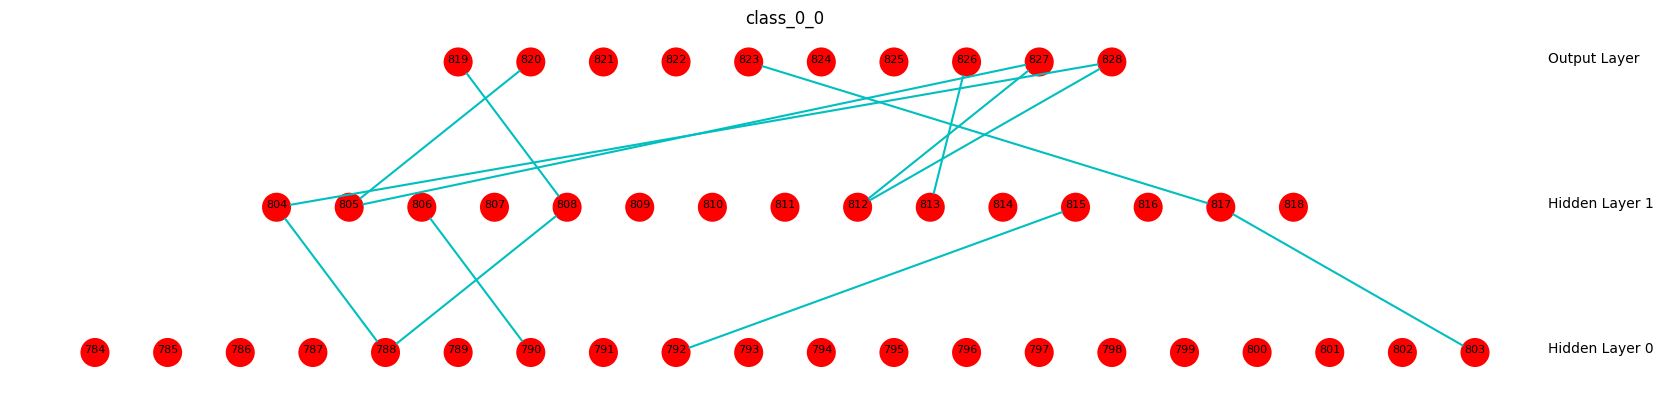

For eps = 0.03, label 0: Has 13 negative edges..., the fraction is 0.003....


For label 1....

{(802, 810), (794, 817), (815, 827), (803, 807), (811, 820), (811, 823), (791, 808), (791, 817), (785, 810), (785, 816), (818, 822), (807, 828), (811, 828), (812, 821), (795, 814), (817, 826), (808, 823), (791, 816), (794, 815), (785, 818)}
Black edges 20, cyan edges 0.


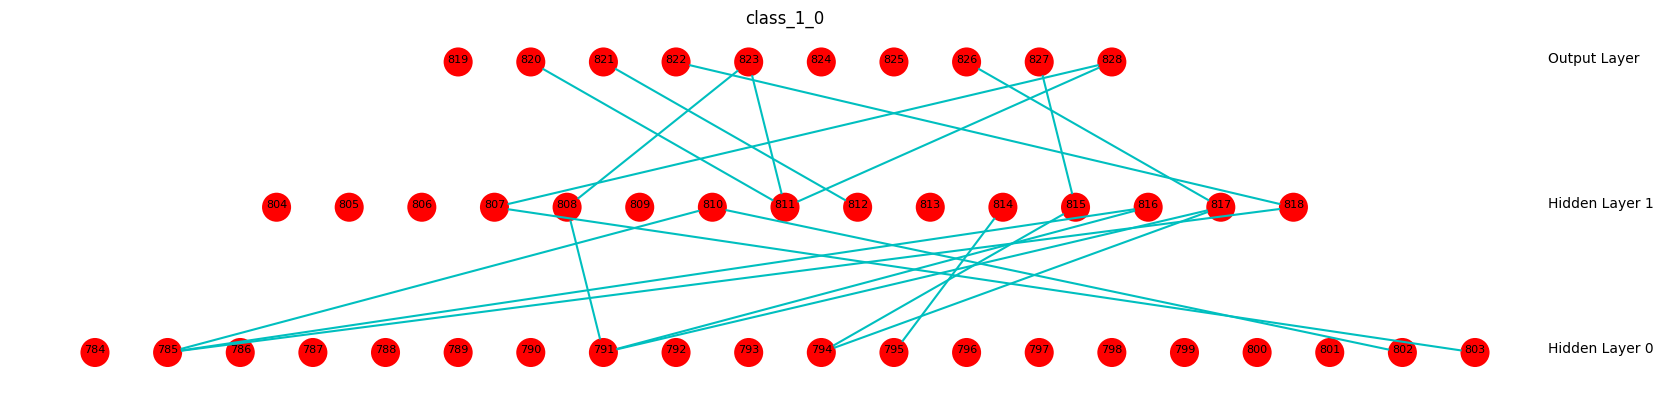

For eps = 0.03, label 1: Has 20 negative edges..., the fraction is 0.010....


For label 2....

{(818, 821), (808, 821), (791, 814), (785, 804), (798, 811), (813, 822), (807, 825), (797, 818), (808, 825), (804, 825), (790, 816), (796, 808)}
Black edges 12, cyan edges 0.


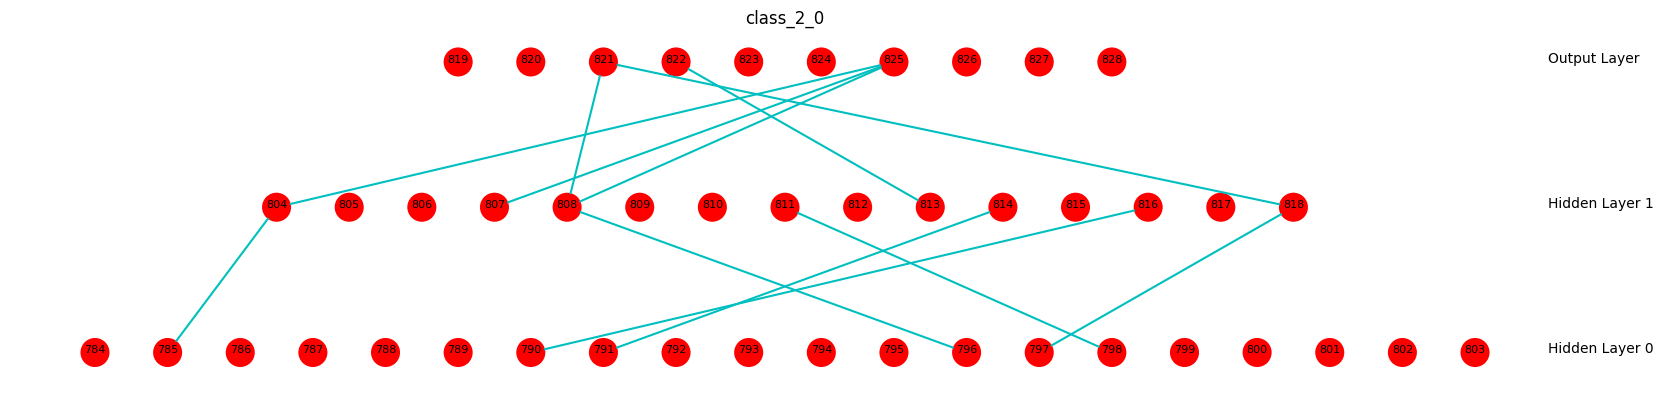

For eps = 0.03, label 2: Has 12 negative edges..., the fraction is 0.003....


For label 3....

{(795, 804), (792, 817), (797, 810), (817, 819), (816, 823), (814, 823), (805, 823), (818, 823), (807, 826), (784, 818), (816, 828), (816, 825), (811, 819), (807, 828), (784, 808), (784, 811), (797, 808), (817, 826), (791, 807), (794, 812)}
Black edges 20, cyan edges 0.


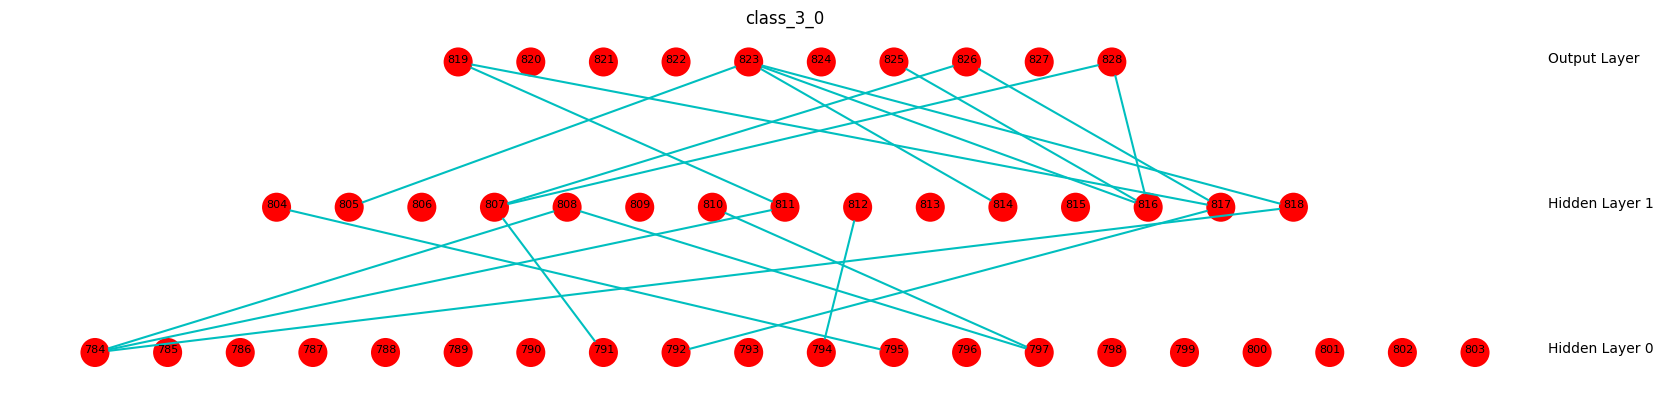

For eps = 0.03, label 3: Has 20 negative edges..., the fraction is 0.007....


For label 4....

{(802, 816), (789, 813), (799, 811), (803, 814), (816, 822), (789, 816), (813, 826), (795, 813), (796, 806), (817, 825), (795, 815), (788, 808), (809, 821), (801, 805), (792, 815)}
Black edges 15, cyan edges 0.


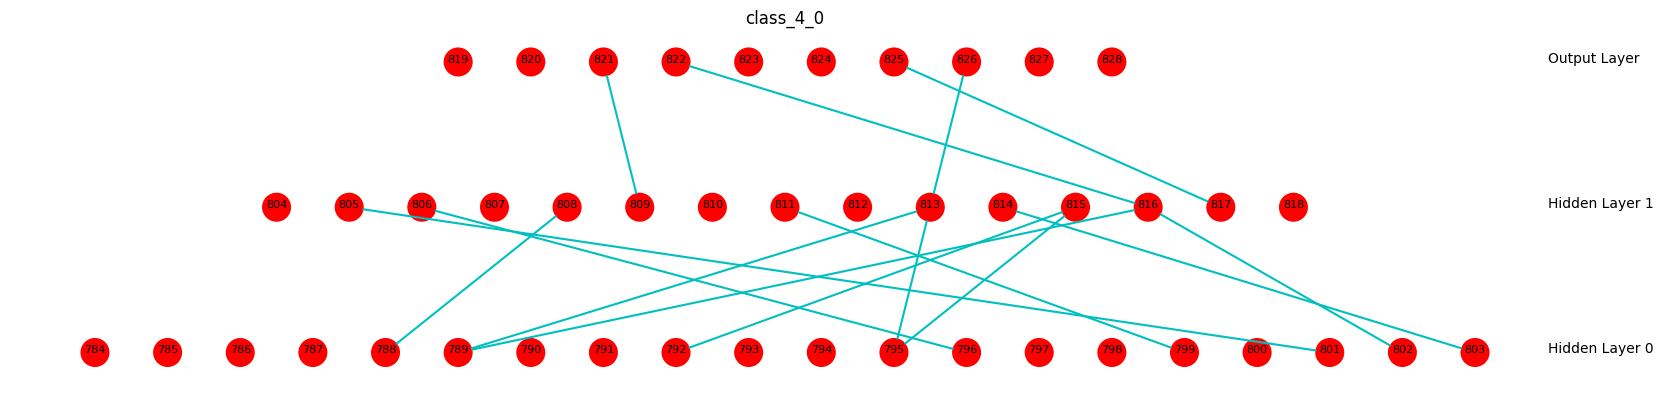

For eps = 0.03, label 4: Has 15 negative edges..., the fraction is 0.006....


For label 5....

{(805, 820), (799, 805), (811, 821), (818, 820), (789, 813), (812, 823), (789, 816), (807, 826), (799, 804), (791, 806), (791, 818), (818, 824)}
Black edges 12, cyan edges 0.


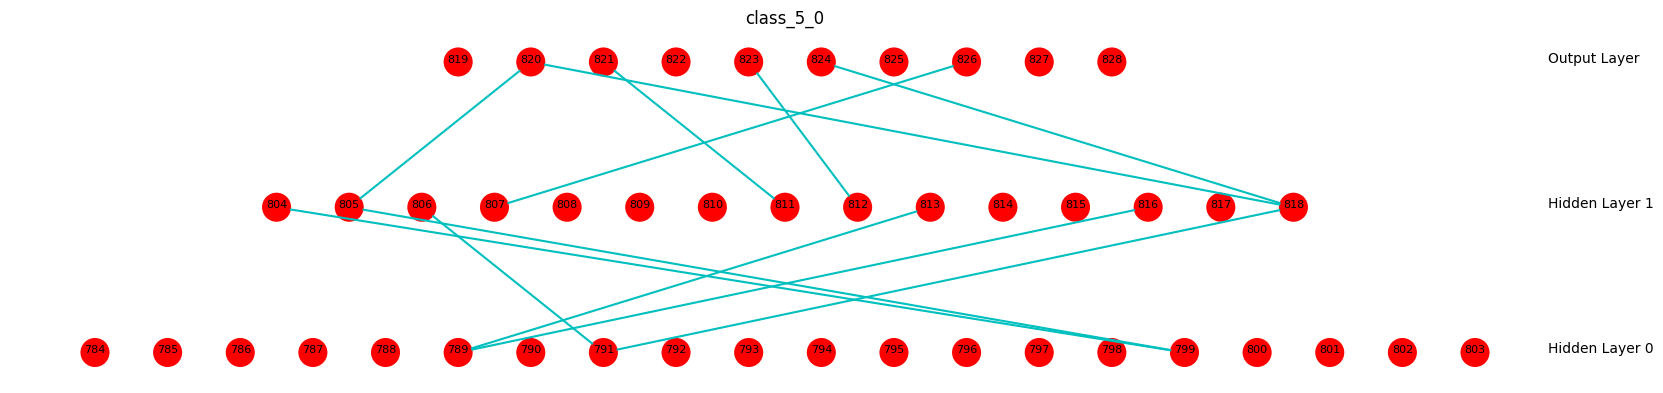

For eps = 0.03, label 5: Has 12 negative edges..., the fraction is 0.004....


For label 6....

{(793, 810), (804, 828), (813, 827), (799, 818), (792, 814), (816, 827), (811, 827), (817, 819), (802, 818), (814, 828), (813, 822), (817, 825), (814, 821), (792, 816), (802, 817)}
Black edges 15, cyan edges 0.


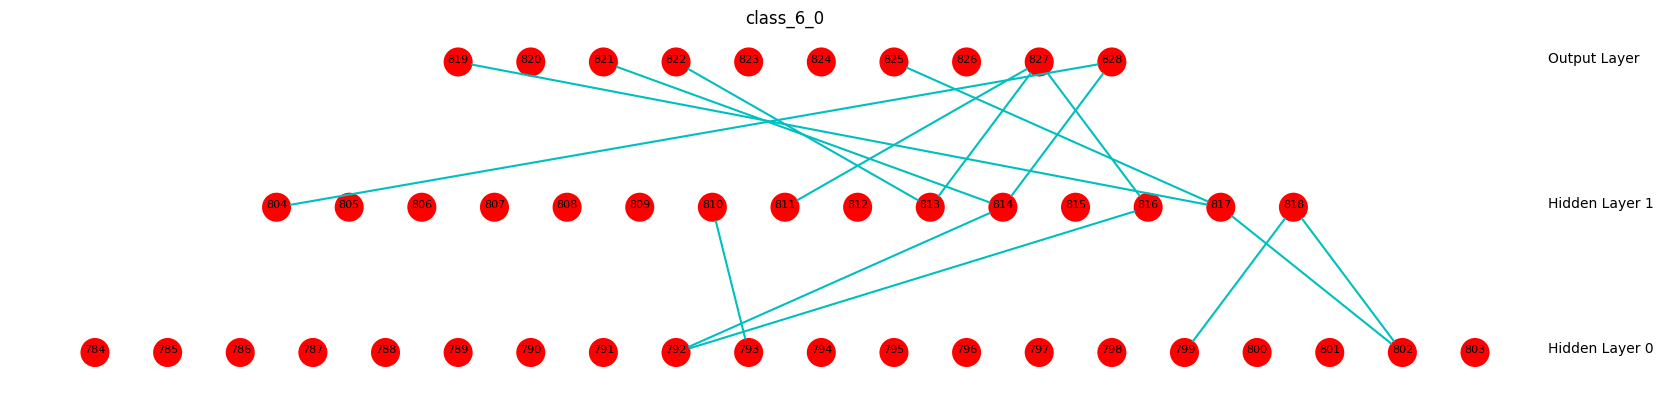

For eps = 0.03, label 6: Has 15 negative edges..., the fraction is 0.004....


For label 7....

{(801, 814), (812, 820), (787, 809), (796, 804), (817, 819), (787, 810), (793, 812), (787, 816), (801, 809), (785, 815), (812, 824)}
Black edges 11, cyan edges 0.


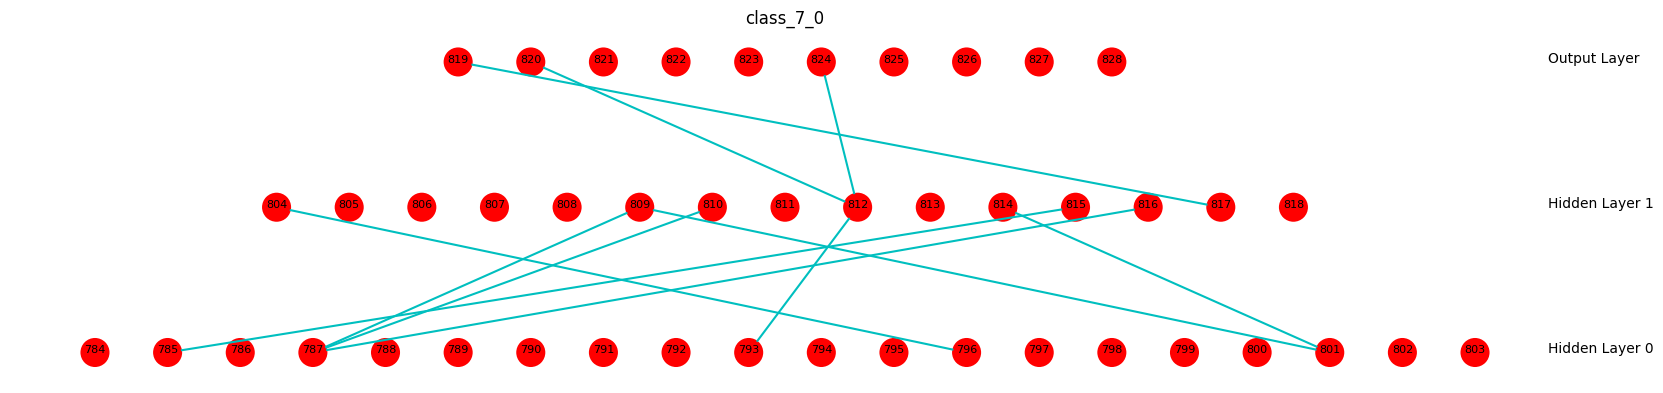

For eps = 0.03, label 7: Has 11 negative edges..., the fraction is 0.004....


For label 8....

{(815, 828), (802, 816), (810, 823), (793, 816), (811, 827), (791, 815), (785, 805), (815, 821), (788, 804), (785, 811), (801, 816), (817, 821), (814, 822), (814, 825), (815, 826), (817, 820), (817, 823), (790, 814), (808, 823), (788, 808), (802, 804)}
Black edges 21, cyan edges 0.


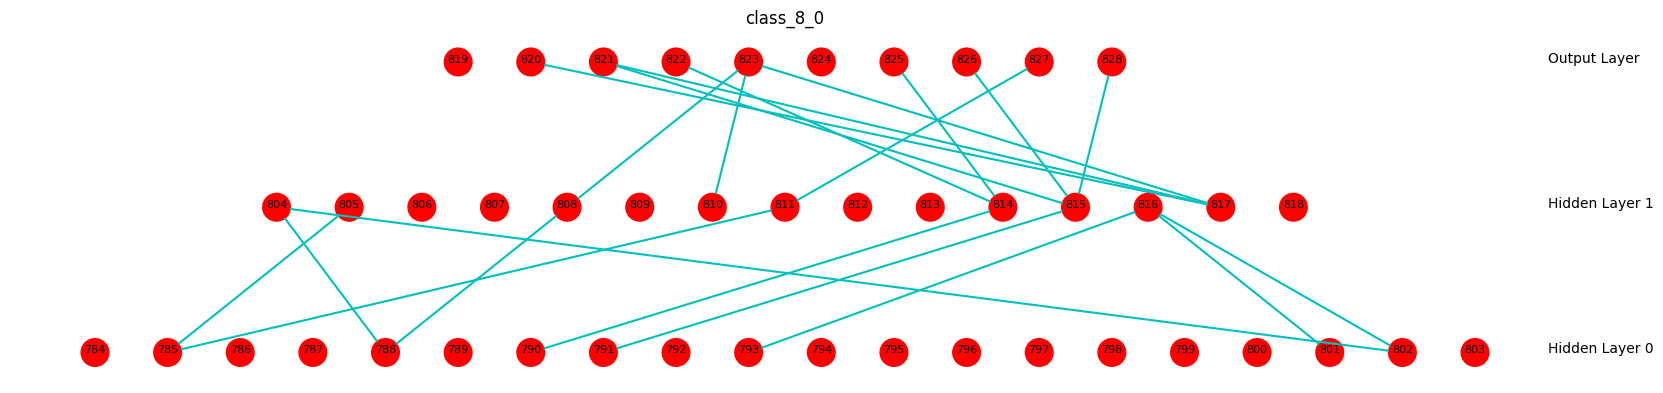

For eps = 0.03, label 8: Has 21 negative edges..., the fraction is 0.005....


For label 9....

{(802, 816), (793, 813), (788, 813), (811, 824), (784, 813), (801, 813), (817, 819), (790, 814), (802, 804), (817, 825), (793, 808), (812, 828), (805, 821), (811, 828), (787, 805)}
Black edges 15, cyan edges 0.


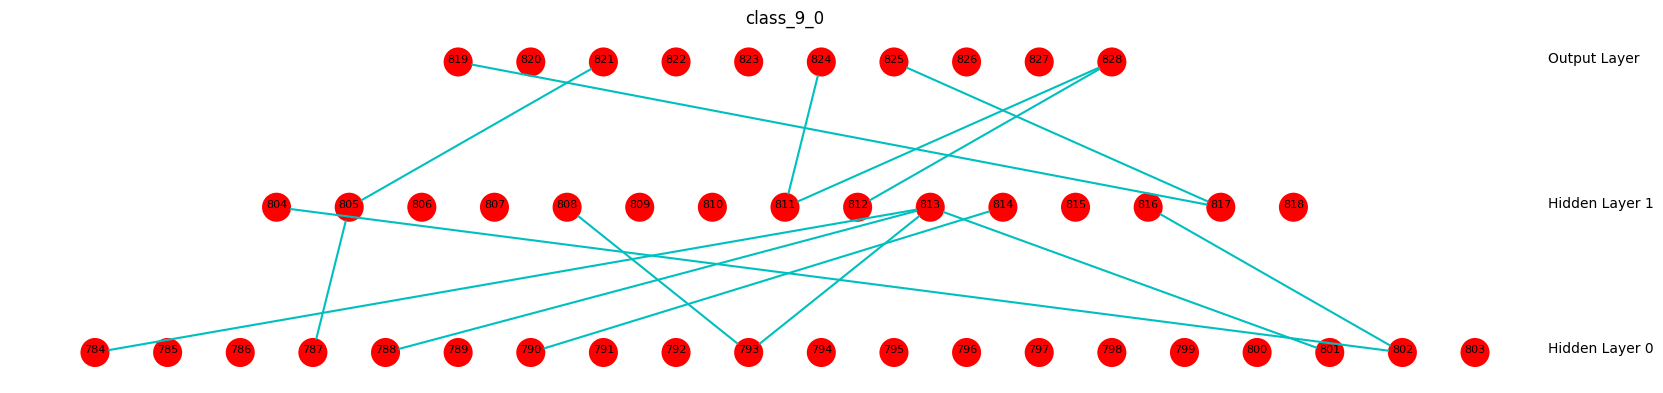

For eps = 0.03, label 9: Has 15 negative edges..., the fraction is 0.004....


Finish label 0....
Finish label 1....
Finish label 2....
Finish label 3....
Finish label 4....
Finish label 5....
Finish label 6....
Finish label 7....
Finish label 8....
Finish label 9....
For label 0....

{(814, 822), (813, 826), (802, 812), (802, 808), (798, 812), (792, 809), (814, 820), (790, 816), (802, 813)}
Black edges 9, cyan edges 0.


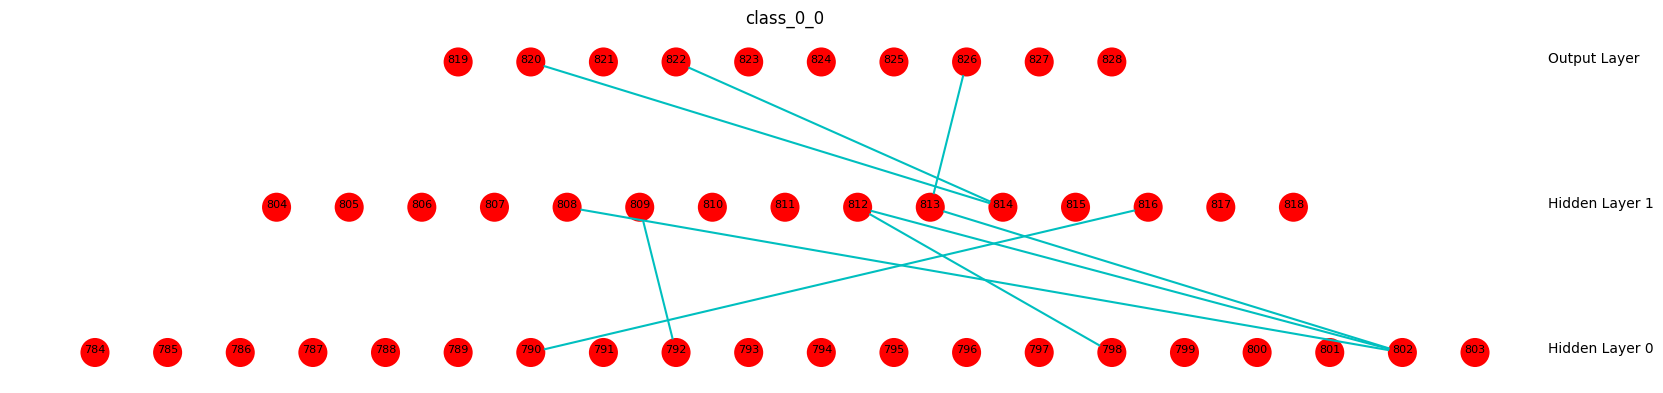

For eps = 0.07, label 0: Has 9 negative edges..., the fraction is 0.002....


For label 1....

For label 2....

{(793, 810), (818, 827), (785, 817), (808, 821), (789, 810), (792, 811), (804, 821), (791, 807), (788, 809), (818, 822), (812, 825), (796, 815), (808, 825), (788, 805), (788, 811), (792, 818)}
Black edges 16, cyan edges 0.


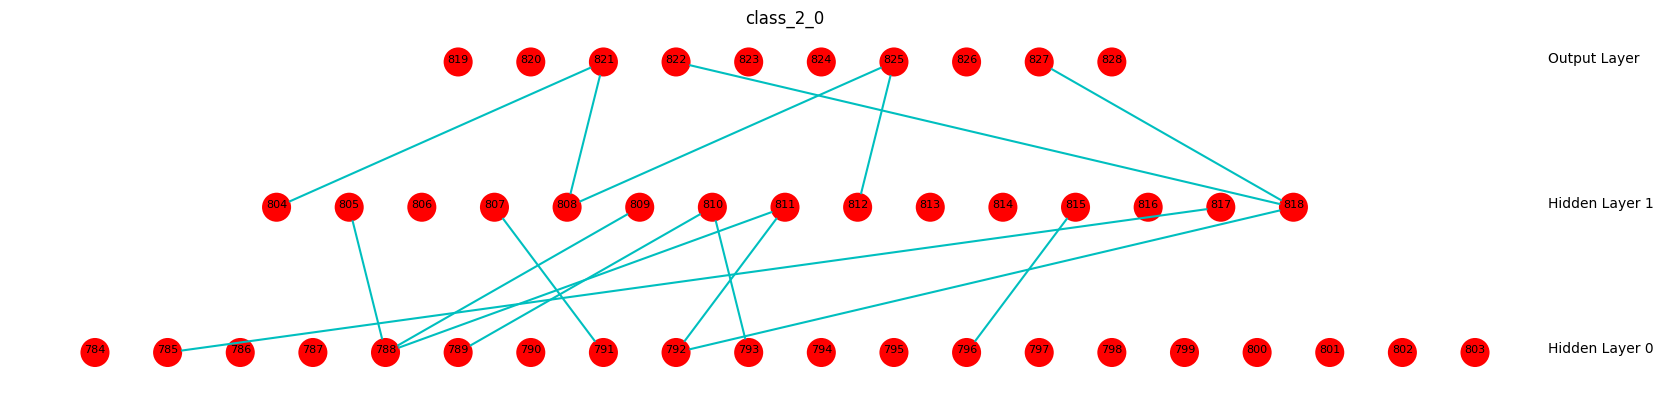

For eps = 0.07, label 2: Has 16 negative edges..., the fraction is 0.004....


For label 3....

{(814, 823), (793, 813), (788, 813), (791, 814), (812, 820), (796, 810), (799, 811), (796, 807), (793, 809), (796, 818), (817, 825), (805, 828), (793, 808), (799, 806), (785, 818), (811, 822)}
Black edges 16, cyan edges 0.


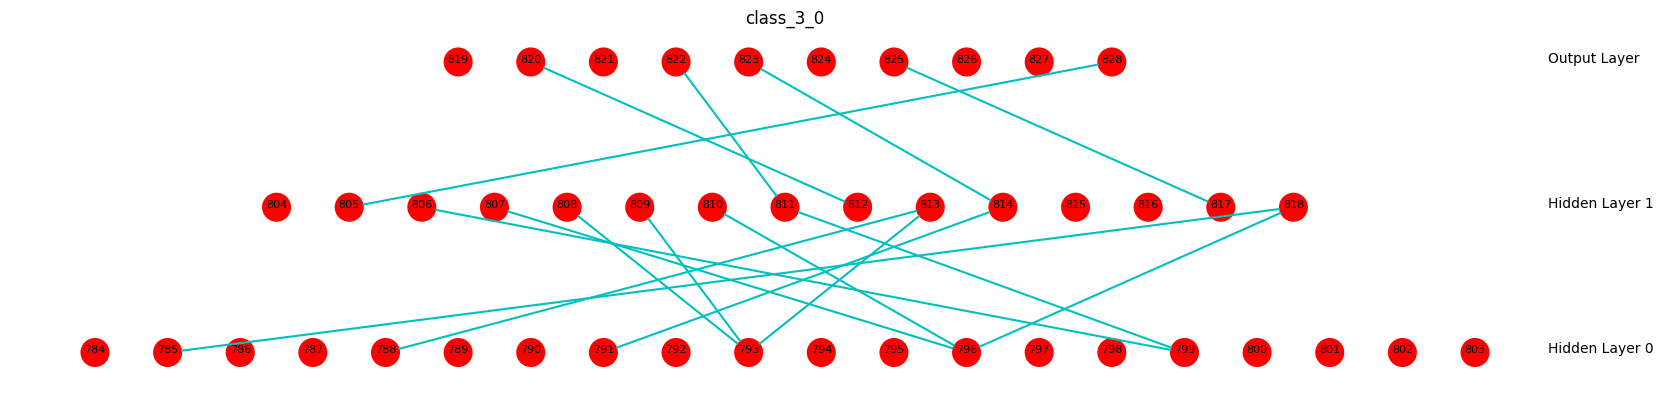

For eps = 0.07, label 3: Has 16 negative edges..., the fraction is 0.004....


For label 4....

{(799, 818), (788, 813), (818, 820), (803, 807), (792, 814), (813, 826), (801, 816), (790, 804), (787, 816), (792, 816), (801, 805), (818, 824), (786, 808)}
Black edges 13, cyan edges 0.


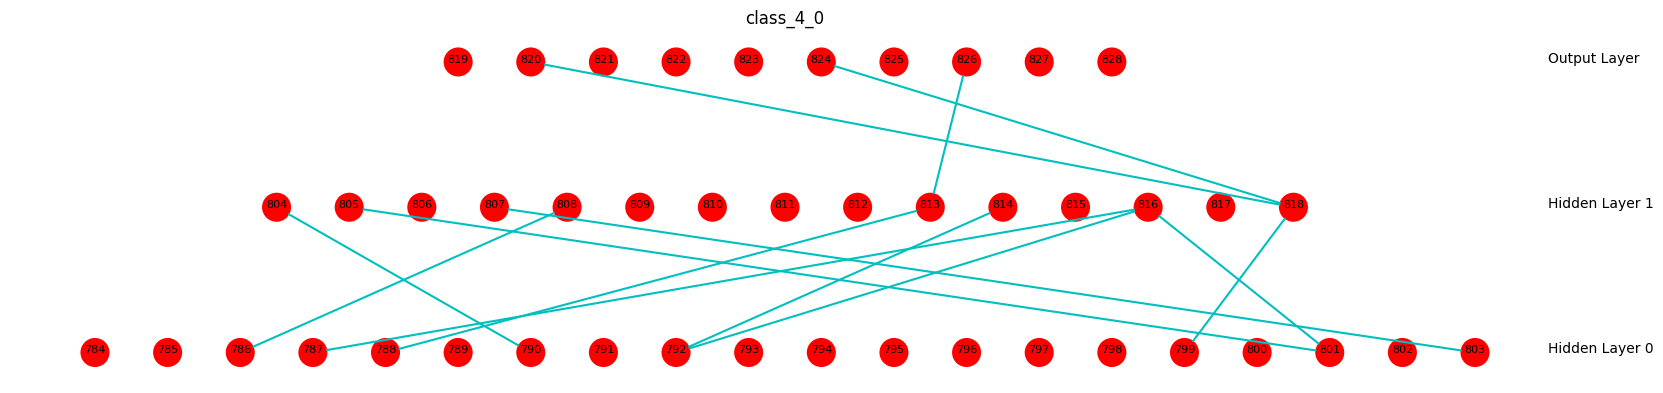

For eps = 0.07, label 4: Has 13 negative edges..., the fraction is 0.004....


For label 5....

{(807, 827), (795, 814), (785, 804), (813, 820), (812, 823), (790, 814), (793, 809), (809, 828), (794, 812), (791, 815), (814, 824), (816, 822), (807, 824), (798, 810)}
Black edges 14, cyan edges 0.


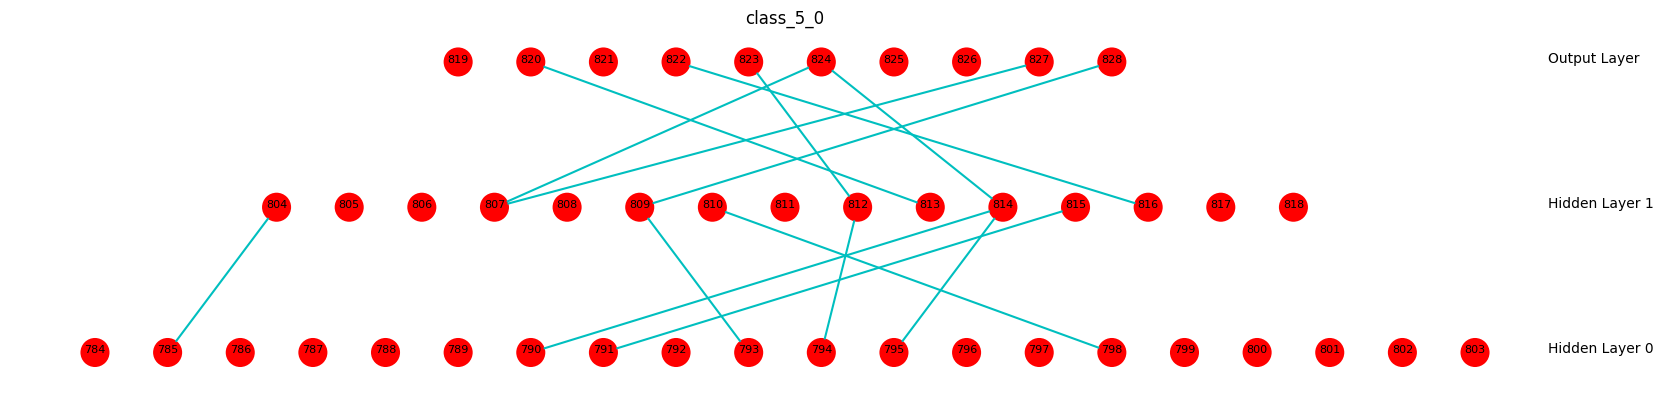

For eps = 0.07, label 5: Has 14 negative edges..., the fraction is 0.004....


For label 6....

{(807, 827), (804, 828), (816, 821), (786, 804), (807, 823), (801, 813), (814, 825), (817, 819), (813, 819), (796, 806), (817, 825), (816, 823), (791, 815), (792, 809), (807, 824), (813, 824), (799, 815)}
Black edges 17, cyan edges 0.


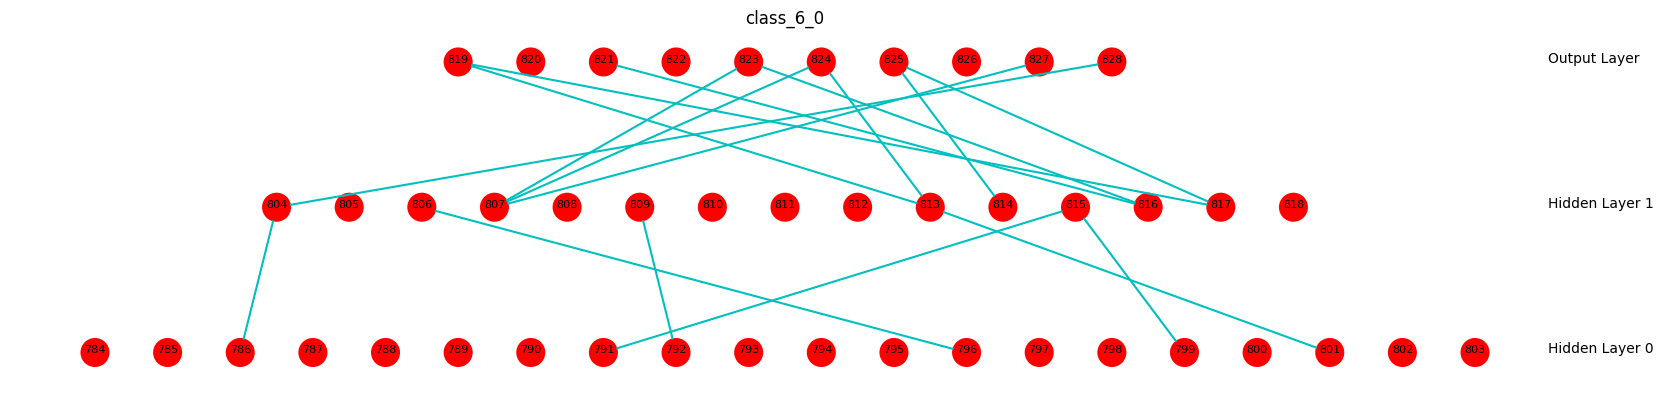

For eps = 0.07, label 6: Has 17 negative edges..., the fraction is 0.005....


For label 7....

{(804, 824), (811, 824), (817, 819), (809, 820), (790, 817), (810, 825), (811, 823), (784, 818), (812, 824), (811, 828), (817, 827), (812, 827)}
Black edges 12, cyan edges 0.


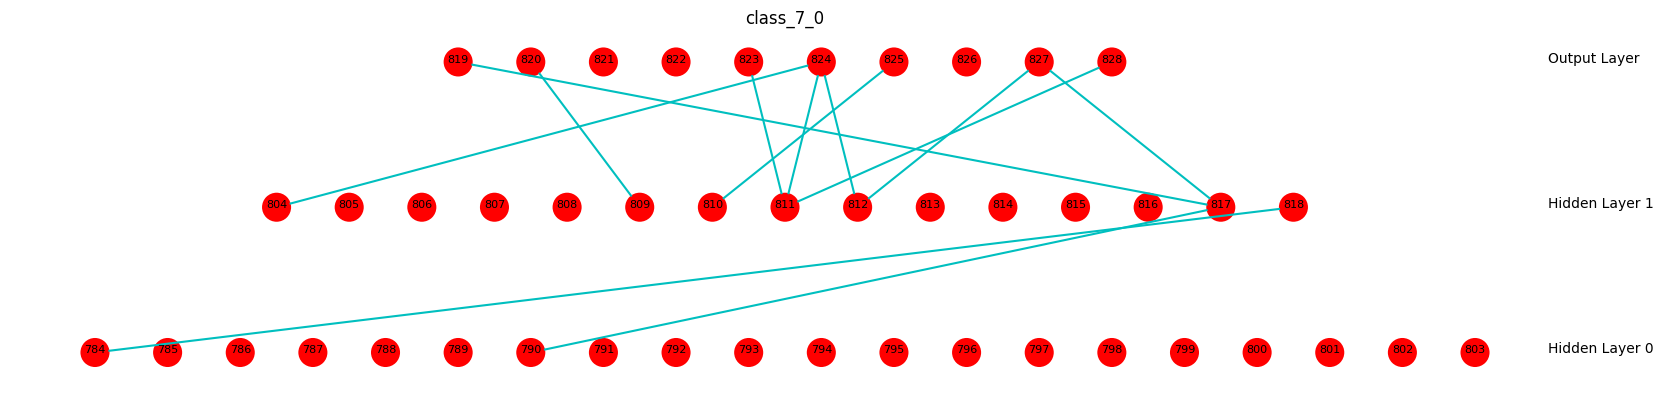

For eps = 0.07, label 7: Has 12 negative edges..., the fraction is 0.003....


For label 8....

{(810, 820), (795, 814), (797, 817), (792, 817), (804, 827), (812, 823), (801, 813), (808, 823), (808, 822), (810, 824), (802, 804)}
Black edges 11, cyan edges 0.


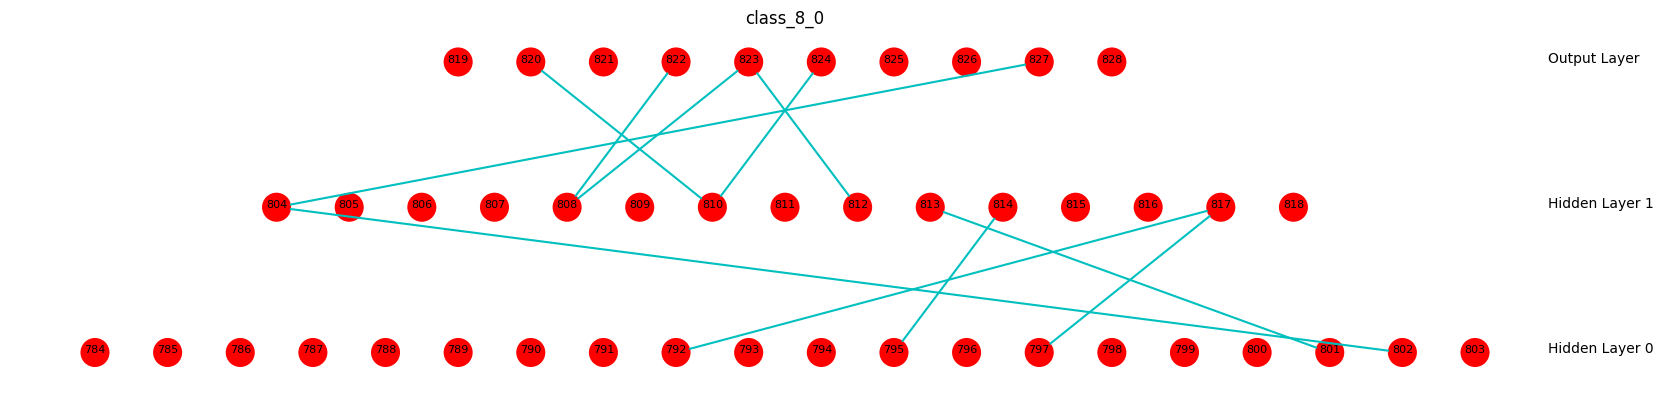

For eps = 0.07, label 8: Has 11 negative edges..., the fraction is 0.002....


For label 9....

{(801, 804), (792, 817), (816, 827), (814, 825), (818, 823), (787, 804), (790, 817), (817, 825), (808, 822), (812, 824)}
Black edges 10, cyan edges 0.


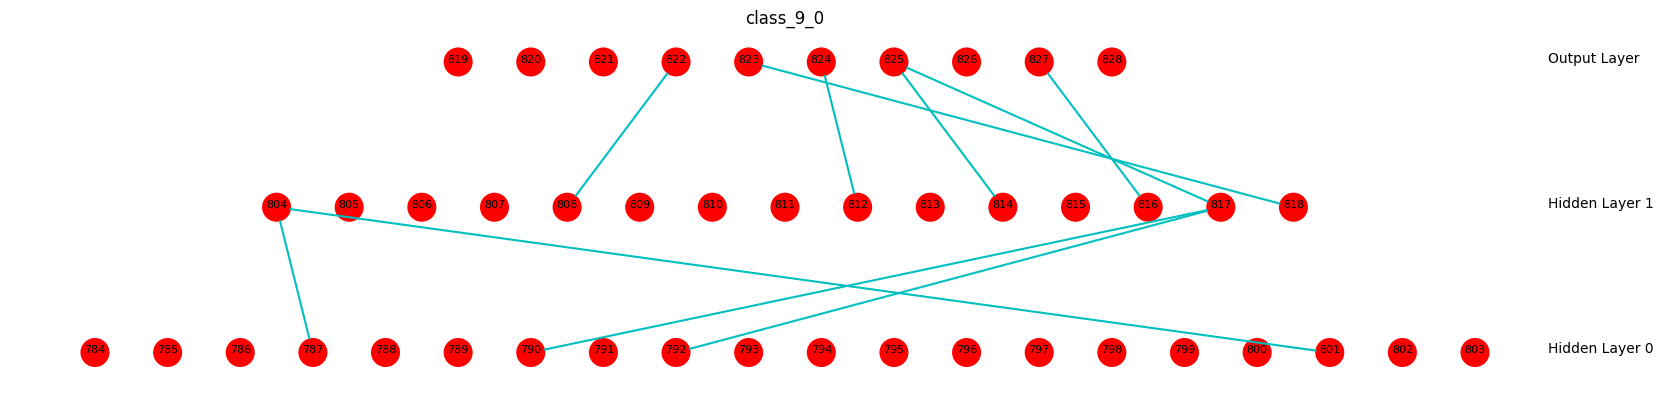

For eps = 0.07, label 9: Has 10 negative edges..., the fraction is 0.004....


Finish label 0....
Finish label 1....
Finish label 2....
Finish label 3....
Finish label 4....
Finish label 5....
Finish label 6....
Finish label 7....
Finish label 8....
Finish label 9....
For label 0....

{(804, 828), (808, 821), (791, 817), (798, 807), (809, 822), (808, 826), (809, 828), (792, 813), (814, 821), (813, 825), (814, 824), (814, 820), (790, 816), (791, 808)}
Black edges 14, cyan edges 0.


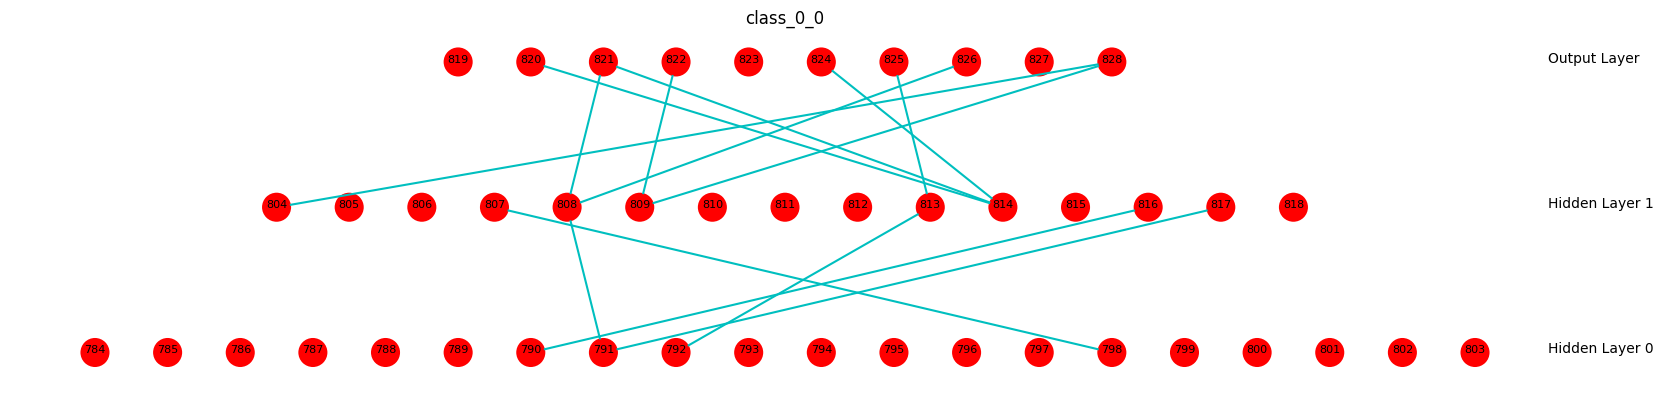

For eps = 0.1, label 0: Has 14 negative edges..., the fraction is 0.002....


For label 1....

For label 2....

{(798, 807), (801, 804), (803, 807), (815, 820), (812, 826), (801, 812), (811, 822), (790, 816), (808, 824)}
Black edges 9, cyan edges 0.


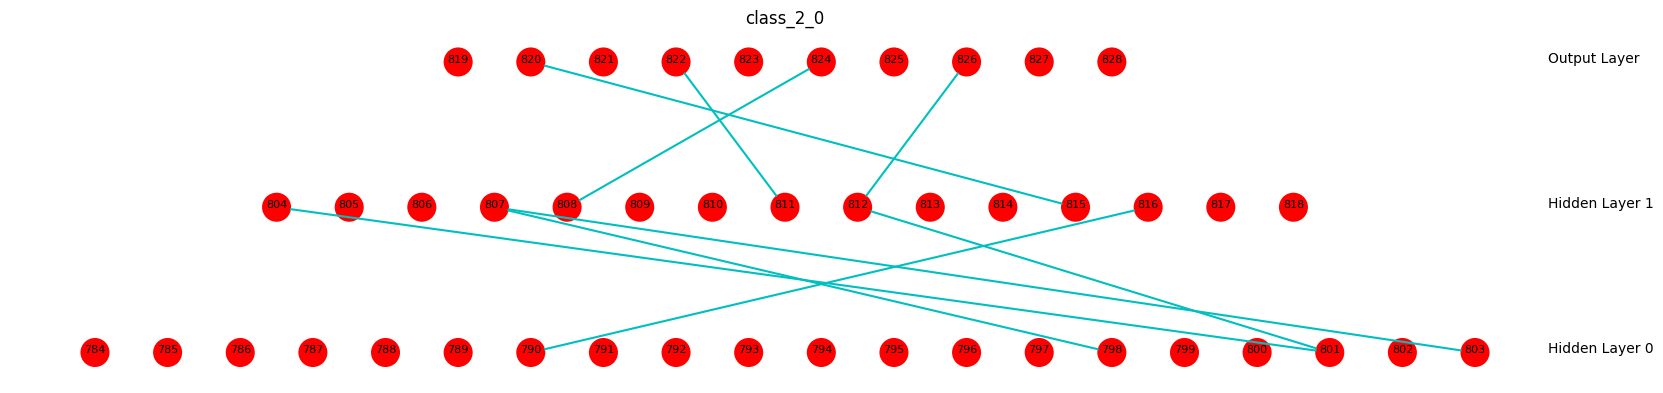

For eps = 0.1, label 2: Has 9 negative edges..., the fraction is 0.003....


For label 3....

{(793, 807), (788, 813), (817, 823), (792, 814), (798, 806), (818, 823), (803, 804), (812, 826), (808, 823), (799, 806), (792, 816), (808, 822), (817, 824), (807, 824), (793, 814), (796, 808)}
Black edges 16, cyan edges 0.


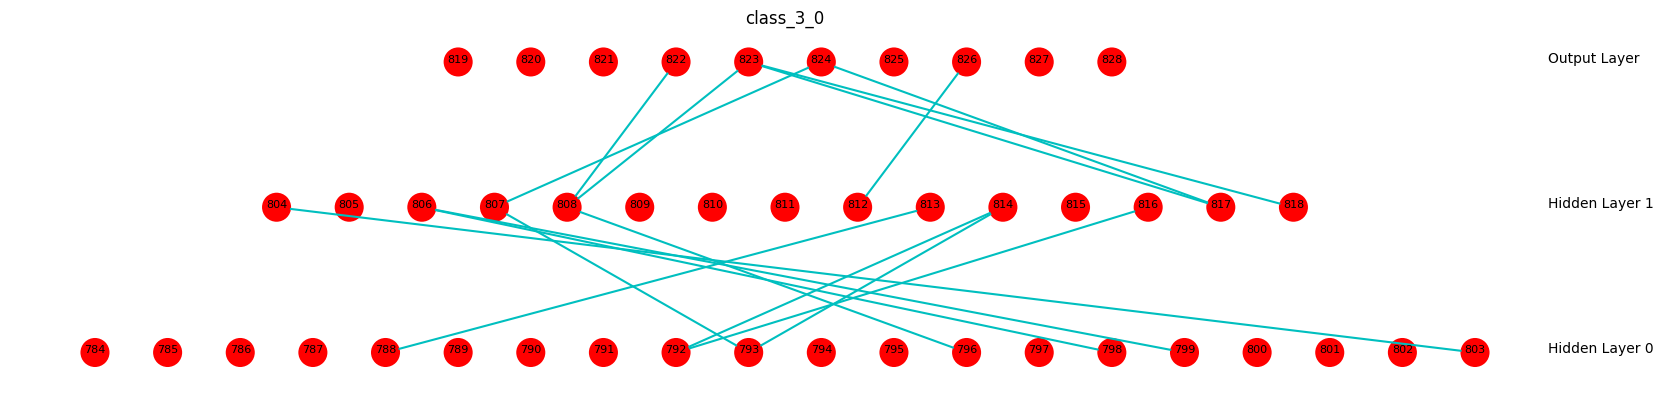

For eps = 0.1, label 3: Has 16 negative edges..., the fraction is 0.005....


For label 4....

For label 5....

For label 6....

For label 7....

For label 8....

{(804, 824), (797, 817), (792, 817), (796, 810), (801, 813), (796, 807), (811, 827), (803, 804), (788, 806), (792, 810), (812, 828), (796, 818)}
Black edges 12, cyan edges 0.


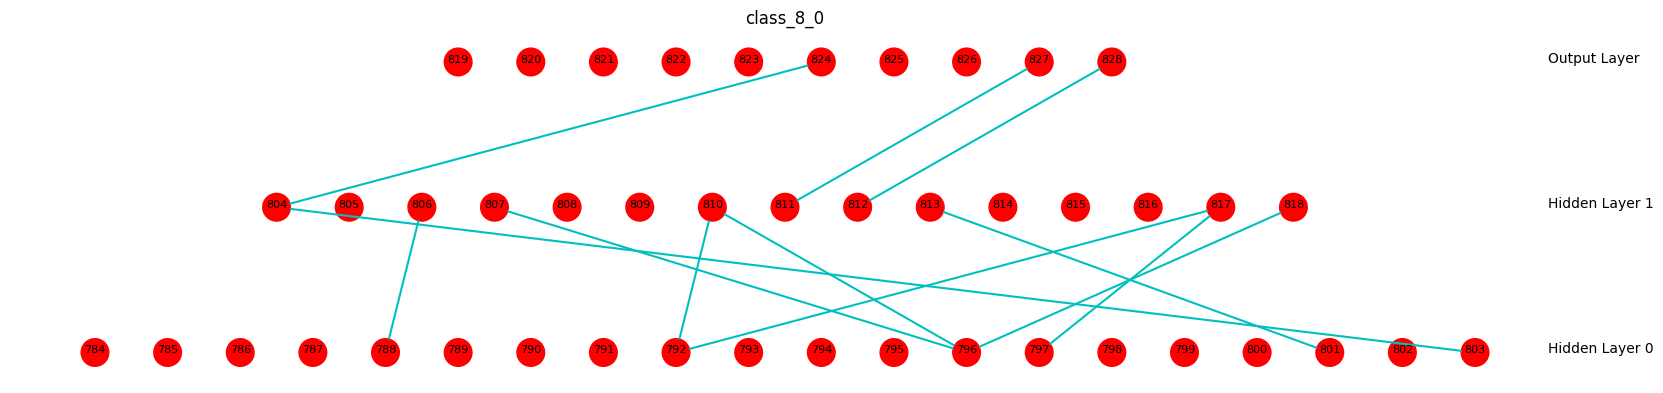

For eps = 0.1, label 8: Has 12 negative edges..., the fraction is 0.002....


For label 9....



In [ ]:
for layer_num in [2]:
    for q in Q:
        # model_name = "best_ori_10l_" + str(layer_num) + ".pth"
        model_name = "best_2_tanh.pth"
        # model_name = "pgdtrain_" + str(layer_num) + ".pth"
        print(f'Now for model {model_name}....\n')
        
        dims = model_zoo[layer_num]
        net_H = FC_MD(dims, layer_num)

        net_H.load_state_dict(torch.load(model_path + model_name))
        net_H = net_H.to(device)
        
        neural_list = []
        nodes_num = 0
        edges_num = 0
        i = 0
        for p in net_H.parameters():
            if i == 0:
                nodes_num += p.shape[1]
            if i%2 == 0:
                nodes_num += p.shape[0]
                edges_num += (p.shape[0] * p.shape[1])
                neural_list.append(p.shape[0])
            i += 1
            
            # start1 = time.perf_counter()
            # total_t = 0.
        for e in eps:
            succ_pair, robust_pair = test(net_H, sep_dataloader, eps=e, alpha=2/255, iters=40)
            
            sample_size = 5
                            
            for l in selected_classes:
                print(f'For label {l}....\n')
                
                var_w = []
                var_w1 = []
                avg_c = []
                avg_c1 = []

                # non robust images
                i = 0
                for (ori_im, adv_im) in robust_pair[l]:
                    for im in ori_im:
                        # start = time.perf_counter()
                        adj_m_ori, nodes_ori = build_adjm(im, net_H, nodes_num, dims, device)
           
                        # Create network object
                        G = nx.from_numpy_array(adj_m_ori, create_using=nx.DiGraph)
        
                        orf = OllivierRicci(G, alpha=0., method="OTD")
                        orf.recal_qexp(q, nodes_ori)
                        orf.compute_ricci_curvature()
                        G1 = orf.G.copy()
    
                        edge_set, remain_edges, w, c = show_results(G1, "ricciCurvature", name = str(l) + str(i) + '_nonrobust')
                        
                        # print(edge_set)
                        # name = f'class_{l}_{i}'
                        # network = DrawNN(dims, edge_set, neural_list)
                        # network.draw(name, '/')

                        print(f'For eps = {e}, label {l}: Has {len(edge_set)} negative edges..., the fraction is {len(edge_set)/(len(remain_edges)+len(edge_set)):.3f}....\n\n')

                        i += 1
            
                        if (i >= sample_size):
                            break